In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from matplotlib import pyplot as plt

from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

**Data Collection and Preprocessing Diabetes Dataset**

In [2]:
# loading the diabetes dataset to a pandas DataFrame
diabetes_dataset = pd.read_csv('/content/diabetes _dataset.csv')

In [3]:
# printing the first 5 rows of the dataset
diabetes_dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# number of rows and Columns in this dataset
diabetes_dataset.shape

(768, 9)

In [5]:
# getting the statistical measures of the data
diabetes_dataset.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
diabetes_dataset['Outcome'].value_counts()

,count
Outcome,
0,500
1,268


0 --> Non-Diabetic

1 --> Diabetic

In [7]:
diabetes_dataset.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,109.980000,68.184000,19.664000,68.792000,30.304200,0.429734,31.190000
1,4.865672,141.257463,70.824627,22.164179,100.335821,35.142537,0.550500,37.067164


In [8]:
print(diabetes_dataset.isnull().sum())

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


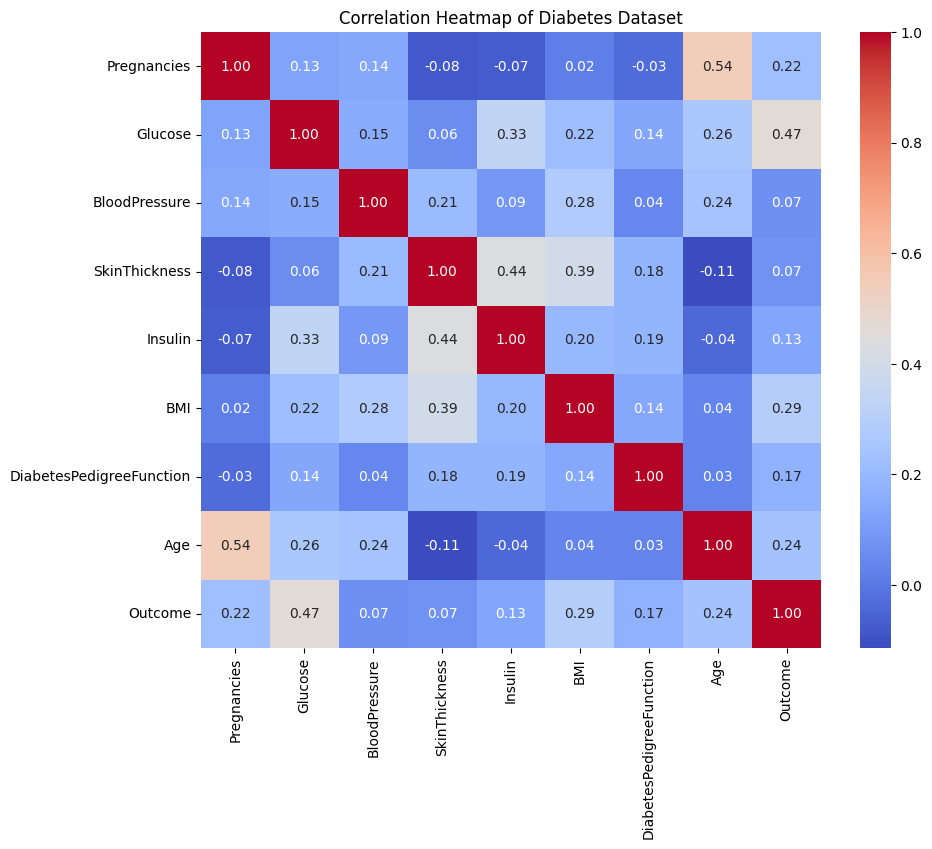

In [9]:
correlation_matrix = diabetes_dataset.corr()

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Diabetes Dataset')
plt.show()

In [10]:
df = diabetes_dataset.copy()

In [11]:
# separating the data and labels
X = df.drop(columns = 'Outcome', axis=1)
Y = df['Outcome']

In [12]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [ ]:
print(Y)

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64


**Train Test Split**

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.2, stratify=Y, random_state=49)

In [14]:
print(X.shape, X_train.shape, X_test.shape)

(768, 8) (614, 8) (154, 8)


Training the Model

**Support Vector Machine (SVM)**

In [15]:
SVM_model = svm.SVC(kernel='linear')

In [16]:
#training the support vector Machine Classifier
SVM_model.fit(X_train, Y_train)

SVC(kernel='linear')

In [17]:
# accuracy score on the training data
X_train_prediction = SVM_model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(training_data_accuracy)

print(f'Accuracy score of the training data: {formatted_accuracy}')

Accuracy score of the training data: 78.18%


In [18]:
# accuracy score on the test data
X_test_prediction = SVM_model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(test_data_accuracy)

print(f'Accuracy score of the test data: {formatted_accuracy}')


Accuracy score of the test data: 75.32%


In [19]:
from sklearn.metrics import precision_score, recall_score, f1_score

Training Data Metrics:
Accuracy: 78.18%
Precision: 77.74%
Recall: 78.18%
F1 Score: 77.42%

Test Data Metrics:
Accuracy: 75.32%
Precision: 74.74%
Recall: 75.32%
F1 Score: 74.81%


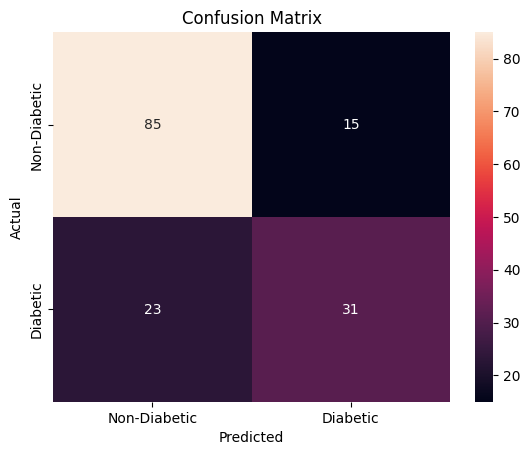

In [20]:
# Calculate accuracy
train_accuracy = accuracy_score(Y_train, X_train_prediction)
test_accuracy = accuracy_score(Y_test, X_test_prediction)

# Calculate precision
train_precision = precision_score(Y_train, X_train_prediction, average='weighted')
test_precision = precision_score(Y_test, X_test_prediction, average='weighted')

# Calculate recall
train_recall = recall_score(Y_train, X_train_prediction, average='weighted')
test_recall = recall_score(Y_test, X_test_prediction, average='weighted')

# Calculate F1 score
train_f1 = f1_score(Y_train, X_train_prediction, average='weighted')
test_f1 = f1_score(Y_test, X_test_prediction, average='weighted')

# Print performance metrics
print("Training Data Metrics:")
print(f"Accuracy: {train_accuracy:.2%}")
print(f"Precision: {train_precision:.2%}")
print(f"Recall: {train_recall:.2%}")
print(f"F1 Score: {train_f1:.2%}")

print("\nTest Data Metrics:")
print(f"Accuracy: {test_accuracy:.2%}")
print(f"Precision: {test_precision:.2%}")
print(f"Recall: {test_recall:.2%}")
print(f"F1 Score: {test_f1:.2%}")

# Plot confusion matrix for test data
cm = metrics.confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



**Decision Trees**

In [22]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import log_loss

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import log_loss, accuracy_score

# Initialize lists to store results
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
max_depths = range(1, 21)

In [24]:
for depth in max_depths:
    dt_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_model.fit(X_train, Y_train)

    # Calculate log loss and accuracy for training data
    y_train_pred_proba = dt_model.predict_proba(X_train)
    y_train_pred = dt_model.predict(X_train)
    train_loss = log_loss(Y_train, y_train_pred_proba)
    train_accuracy = accuracy_score(Y_train, y_train_pred)
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # Calculate log loss and accuracy for validation (test) data
    y_val_pred_proba = dt_model.predict_proba(X_test)
    y_val_pred = dt_model.predict(X_test)
    val_loss = log_loss(Y_test, y_val_pred_proba)
    val_accuracy = accuracy_score(Y_test, y_val_pred)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

In [25]:
# Print the best validation accuracy and its corresponding depth
best_val_accuracy = max(val_accuracies)
best_depth = max_depths[val_accuracies.index(best_val_accuracy)]
print(f"Best validation accuracy: {best_val_accuracy:.2f} at max_depth = {best_depth}")

# Print final training and test accuracies at the best depth
dt_model_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_model_best.fit(X_train, Y_train)

final_train_accuracy = accuracy_score(Y_train, dt_model_best.predict(X_train))
final_test_accuracy = accuracy_score(Y_test, dt_model_best.predict(X_test))

print(f"Final Training Accuracy at max_depth={best_depth}: {final_train_accuracy:.2f}")
print(f"Final Test Accuracy at max_depth={best_depth}: {final_test_accuracy:.2f}")

Best validation accuracy: 0.75 at max_depth = 6
Final Training Accuracy at max_depth=6: 0.88
Final Test Accuracy at max_depth=6: 0.75



Test Data Metrics:
Accuracy: 68.18%
Precision: 68.61%
Recall: 68.18%
F1 Score: 68.37%


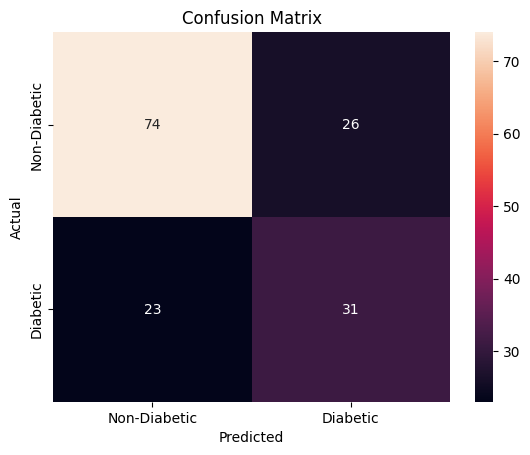

In [26]:
# Calculate accuracy
val_accuracy = accuracy_score(Y_test, y_val_pred)

# Calculate precision
val_precision = precision_score(Y_test, y_val_pred, average='weighted')

# Calculate recall
val_recall = recall_score(Y_test, y_val_pred, average='weighted')

# Calculate F1 score
val_f1 = f1_score(Y_test, y_val_pred, average='weighted')

print("\nTest Data Metrics:")
print(f"Accuracy: {val_accuracy:.2%}")
print(f"Precision: {val_precision:.2%}")
print(f"Recall: {val_recall:.2%}")
print(f"F1 Score: {val_f1:.2%}")

# Plot confusion matrix for test data
cm = metrics.confusion_matrix(Y_test, y_val_pred)
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
print(classification_report(Y_test, y_val_pred))

              precision    recall  f1-score   support

           0       0.76      0.74      0.75       100
           1       0.54      0.57      0.56        54

    accuracy                           0.68       154
   macro avg       0.65      0.66      0.65       154
weighted avg       0.69      0.68      0.68       154



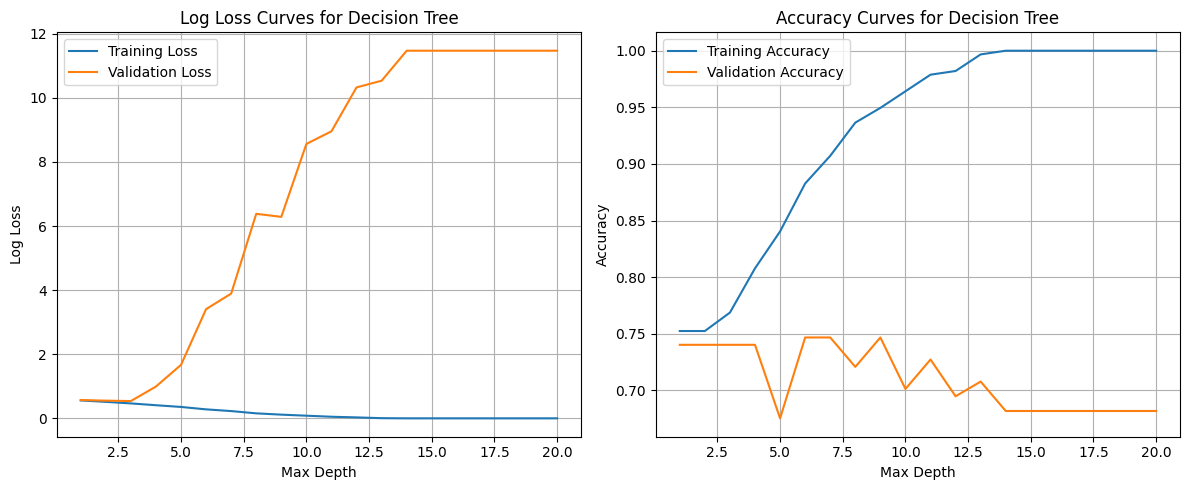

In [28]:
# Plot the loss curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(max_depths, train_losses, label='Training Loss')
plt.plot(max_depths, val_losses, label='Validation Loss')
plt.xlabel('Max Depth')
plt.ylabel('Log Loss')
plt.title('Log Loss Curves for Decision Tree')
plt.legend()
plt.grid(True)

# Plot the accuracy curves
plt.subplot(1, 2, 2)
plt.plot(max_depths, train_accuracies, label='Training Accuracy')
plt.plot(max_depths, val_accuracies, label='Validation Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves for Decision Tree')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Gradient Boosting**

In [29]:
from sklearn.ensemble import GradientBoostingClassifier

In [30]:
# Create a Gradient Boosting classifier with default 'deviance' loss
gb_model = GradientBoostingClassifier()

# Train the model with training data
gb_model.fit(X_train, Y_train)

GradientBoostingClassifier()

In [31]:
# accuracy score on training data
X_train_prediction = gb_model.predict(X_train)
training_data_accuracy = accuracy_score(Y_train, X_train_prediction)

# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(training_data_accuracy)

print(f'Accuracy score of the training data: {formatted_accuracy}')

Accuracy score of the training data: 93.32%


In [32]:
# accuracy score on testing data
X_test_prediction = gb_model.predict(X_test)
test_data_accuracy = accuracy_score(Y_test, X_test_prediction)

# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(test_data_accuracy)

print(f'Accuracy score of the testing data: {formatted_accuracy}')

Accuracy score of the testing data: 76.62%


Training Data Metrics:
Accuracy: 93.32%
Precision: 93.43%
Recall: 93.32%
F1 Score: 93.23%

Test Data Metrics:
Accuracy: 76.62%
Precision: 76.44%
Recall: 76.62%
F1 Score: 76.52%


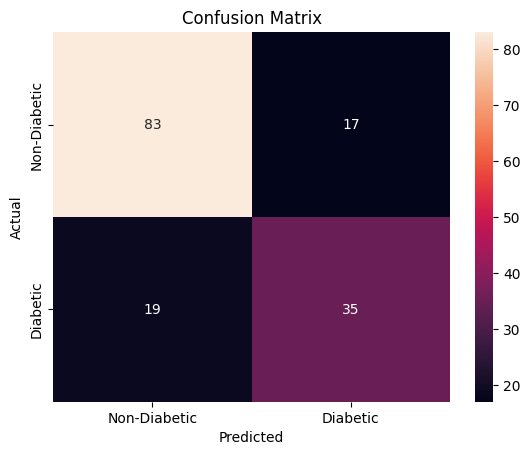

In [33]:
# Calculate accuracy
train_accuracy = accuracy_score(Y_train, X_train_prediction)
test_accuracy = accuracy_score(Y_test, X_test_prediction)

# Calculate precision
train_precision = precision_score(Y_train, X_train_prediction, average='weighted')
test_precision = precision_score(Y_test, X_test_prediction, average='weighted')

# Calculate recall
train_recall = recall_score(Y_train, X_train_prediction, average='weighted')
test_recall = recall_score(Y_test, X_test_prediction, average='weighted')

# Calculate F1 score
train_f1 = f1_score(Y_train, X_train_prediction, average='weighted')
test_f1 = f1_score(Y_test, X_test_prediction, average='weighted')

# Print performance metrics
print("Training Data Metrics:")
print(f"Accuracy: {train_accuracy:.2%}")
print(f"Precision: {train_precision:.2%}")
print(f"Recall: {train_recall:.2%}")
print(f"F1 Score: {train_f1:.2%}")

print("\nTest Data Metrics:")
print(f"Accuracy: {test_accuracy:.2%}")
print(f"Precision: {test_precision:.2%}")
print(f"Recall: {test_recall:.2%}")
print(f"F1 Score: {test_f1:.2%}")

# Plot confusion matrix for test data
cm = metrics.confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [34]:
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.81      0.83      0.82       100
           1       0.67      0.65      0.66        54

    accuracy                           0.77       154
   macro avg       0.74      0.74      0.74       154
weighted avg       0.76      0.77      0.77       154



**Logistic Regression**

In [35]:
from sklearn.linear_model import LogisticRegression
lg_model = LogisticRegression()

In [36]:
# training the LogisticRegression model with Training data
lg_model.fit(X_train, Y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Model Evaluation

Accuracy Score

In [37]:
# accuracy on training data
X_train_prediction = lg_model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(training_data_accuracy)

print(f'Accuracy score of the training data: {formatted_accuracy}')

Accuracy score of the training data: 78.34%


In [38]:
# accuracy on test data
X_test_prediction = lg_model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

# Convert accuracy score to percentage format
formatted_accuracy = "{:.2%}".format(test_data_accuracy)

print(f'Accuracy score of the testing data: {formatted_accuracy}')

Accuracy score of the testing data: 77.27%


Training Data Metrics:
Accuracy: 78.34%
Precision: 77.90%
Recall: 78.34%
F1 Score: 77.64%

Test Data Metrics:
Accuracy: 77.27%
Precision: 76.76%
Recall: 77.27%
F1 Score: 76.73%


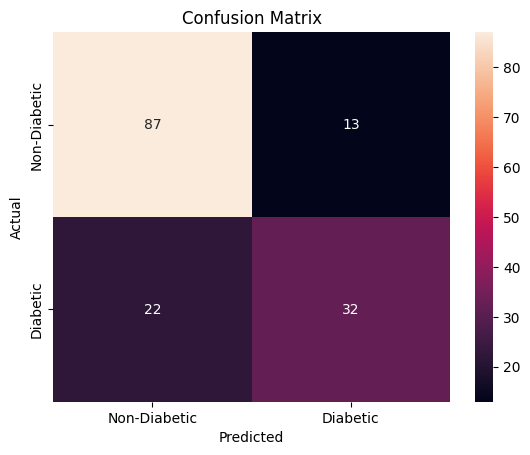

In [39]:
# Calculate accuracy
train_accuracy = accuracy_score(Y_train, X_train_prediction)
test_accuracy = accuracy_score(Y_test, X_test_prediction)

# Calculate precision
train_precision = precision_score(Y_train, X_train_prediction, average='weighted')
test_precision = precision_score(Y_test, X_test_prediction, average='weighted')

# Calculate recall
train_recall = recall_score(Y_train, X_train_prediction, average='weighted')
test_recall = recall_score(Y_test, X_test_prediction, average='weighted')

# Calculate F1 score
train_f1 = f1_score(Y_train, X_train_prediction, average='weighted')
test_f1 = f1_score(Y_test, X_test_prediction, average='weighted')

# Print performance metrics
print("Training Data Metrics:")
print(f"Accuracy: {train_accuracy:.2%}")
print(f"Precision: {train_precision:.2%}")
print(f"Recall: {train_recall:.2%}")
print(f"F1 Score: {train_f1:.2%}")

print("\nTest Data Metrics:")
print(f"Accuracy: {test_accuracy:.2%}")
print(f"Precision: {test_precision:.2%}")
print(f"Recall: {test_recall:.2%}")
print(f"F1 Score: {test_f1:.2%}")

# Plot confusion matrix for test data
cm = metrics.confusion_matrix(Y_test, X_test_prediction)
sns.heatmap(cm, annot=True, fmt="g",
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
print(classification_report(Y_test, X_test_prediction))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       100
           1       0.71      0.59      0.65        54

    accuracy                           0.77       154
   macro avg       0.75      0.73      0.74       154
weighted avg       0.77      0.77      0.77       154



Performance Metrics Comparison:
              Model  Accuracy  Precision  Recall  F1-Score
                SVM     78.18      77.74   78.18     77.42
      Decision Tree     88.00      77.00   74.00     75.00
  Gradient Boosting     93.32      93.43   93.32     93.23
Logistic Regression     78.34      78.34   78.34     77.64


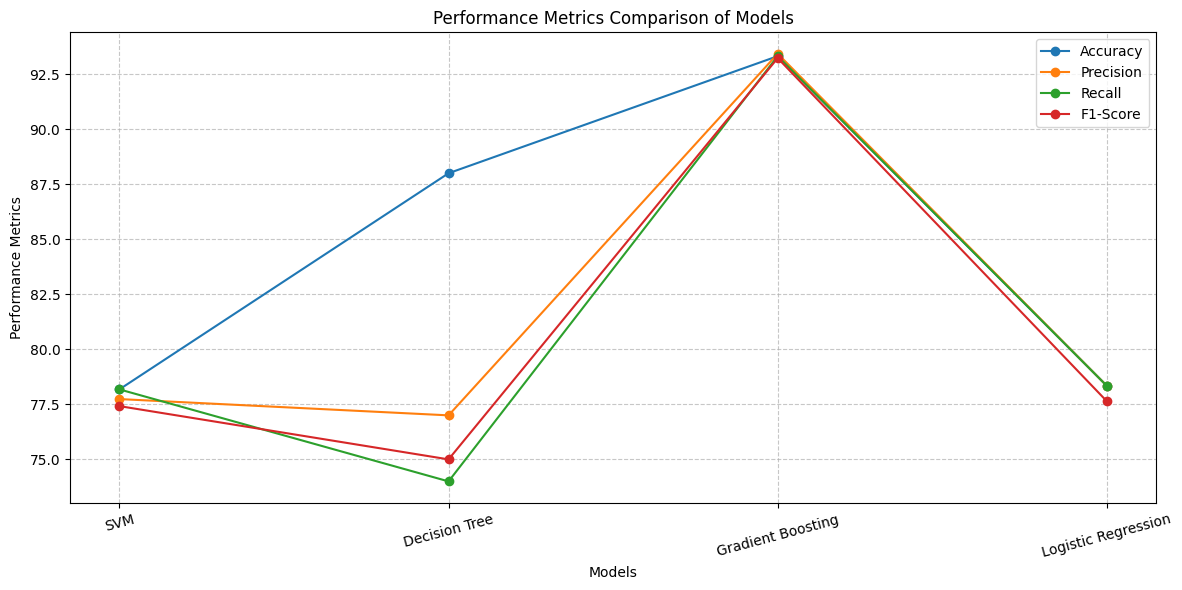

In [75]:
data = {
    'Model': ['SVM', 'Decision Tree', 'Gradient Boosting', 'Logistic Regression'],
    'Accuracy': [78.18, 88.0, 93.32, 78.34],
    'Precision': [77.74, 77, 93.43, 78.34],
    'Recall': [78.18, 74.0, 93.32, 78.34],
    'F1-Score': [77.42, 75.0, 93.23, 77.64]
}

metrics_df = pd.DataFrame(data)

# Display the table
print("Performance Metrics Comparison:")
print(metrics_df.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    plt.plot(metrics_df['Model'], metrics_df[metric], marker='o', linestyle='-', label=metric)

plt.xlabel('Models')
plt.ylabel('Performance Metrics')
plt.title('Performance Metrics Comparison of Models')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [42]:
# Separate rows where Outcome is 1 and 0
outcome_1 = diabetes_dataset[diabetes_dataset['Outcome'] == 1]
outcome_0 = diabetes_dataset[diabetes_dataset['Outcome'] == 0]

# Calculate the range (max - min) for each feature for both outcomes
range_outcome_1 = outcome_1.drop(columns=['Outcome']).max() - outcome_1.drop(columns=['Outcome']).min()
range_outcome_0 = outcome_0.drop(columns=['Outcome']).max() - outcome_0.drop(columns=['Outcome']).min()

print("Range for Outcome 1 (Diabetic):")
print(range_outcome_1)
print("\nRange for Outcome 0 (Non-Diabetic):")
print(range_outcome_0)


Range for Outcome 1 (Diabetic):
Pregnancies                  17.000
Glucose                     199.000
BloodPressure               114.000
SkinThickness                99.000
Insulin                     846.000
BMI                          67.100
DiabetesPedigreeFunction      2.332
Age                          49.000
dtype: float64

Range for Outcome 0 (Non-Diabetic):
Pregnancies                  13.000
Glucose                     197.000
BloodPressure               122.000
SkinThickness                60.000
Insulin                     744.000
BMI                          57.300
DiabetesPedigreeFunction      2.251
Age                          60.000
dtype: float64


In [43]:
def get_feature_ranges(diabetes_dataset):
    ranges = {}
    for feature in diabetes_dataset.columns[:-1]:  # Exclude 'Outcome' column
        outcome_1_range = diabetes_dataset[diabetes_dataset['Outcome'] == 1][feature]
        outcome_0_range = diabetes_dataset[diabetes_dataset['Outcome'] == 0][feature]

        ranges[feature] = {
            'Outcome 1 (Diabetic)': f'{min(outcome_1_range)} - {max(outcome_1_range)}',
            'Outcome 0 (Non-Diabetic)': f'{min(outcome_0_range)} - {max(outcome_0_range)}'
        }

    return pd.DataFrame(ranges).T

# Get and display the ranges
feature_ranges = get_feature_ranges(diabetes_dataset)
print("Feature ranges for each outcome:")
print(feature_ranges)

Feature ranges for each outcome:
                         Outcome 1 (Diabetic) Outcome 0 (Non-Diabetic)
Pregnancies                            0 - 17                   0 - 13
Glucose                               0 - 199                  0 - 197
BloodPressure                         0 - 114                  0 - 122
SkinThickness                          0 - 99                   0 - 60
Insulin                               0 - 846                  0 - 744
BMI                                0.0 - 67.1               0.0 - 57.3
DiabetesPedigreeFunction         0.088 - 2.42            0.078 - 2.329
Age                                   21 - 70                  21 - 81


Building a Predictive System

In [44]:
input_data = (5,166,72,19,175,25.8,0.587,51)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = gb_model.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[1]
The person is diabetic


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [46]:
input_data = (0,706,80,15,30,22,0.2,25)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = gb_model.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[0]
The person is not diabetic


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


Saving the trained model

In [47]:
import pickle

In [48]:
# filename = 'diabetes_model.sav'
pickle.dump(dt_model, open('diabetes_model.sav', 'wb'))

In [49]:
# # loading the saved model
loaded_model = pickle.load(open('diabetes_model.sav', 'rb'))

In [50]:
input_data = (0,706,80,15,30,22,0.2,25)

# changing the input_data to numpy array
input_data_as_numpy_array = np.asarray(input_data)

# reshape the array as we are predicting for one instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = loaded_model.predict(input_data_reshaped)
print(prediction)

if (prediction[0] == 0):
  print('The person is not diabetic')
else:
  print('The person is diabetic')

[0]
The person is not diabetic


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [51]:
for column in X.columns:
  print(column)

Pregnancies
Glucose
BloodPressure
SkinThickness
Insulin
BMI
DiabetesPedigreeFunction
Age


**IMPLEMENTATION OF XAI MODELS**

In [52]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=42ed1f7ba0fd7c33c27ff0014b3477b4b161f6f817b162064a36633ec7c0a9eb
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [53]:
import shap
import lime
import lime.lime_tabular

In [78]:
# SHAP implementation
explainer_shap = shap.Explainer(gb_model.predict, X_test)
shap_values = explainer_shap(X_test)

ExactExplainer explainer: 155it [00:10,  1.75s/it]


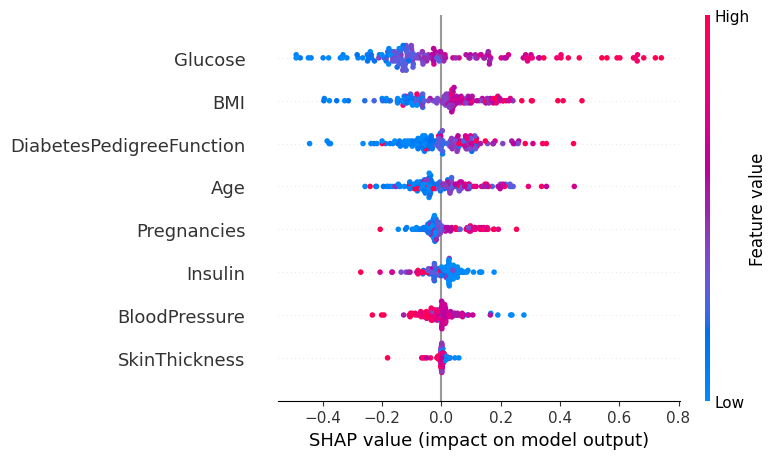

In [79]:
# Summary plot to visualize feature importance using SHAP
shap.summary_plot(shap_values, X_test)

The SHAP summary plot shows the impact of different features on a diabetes prediction model. Glucose, BMI, and Diabetes Pedigree Function (DPF) are the most influential factors. Higher glucose and BMI values significantly increase the likelihood of diabetes. Age and pregnancies also contribute, while features like blood pressure and insulin have a lower impact. The color gradient indicates feature values, with red (high values) pushing the model towards predicting diabetes and blue (low values) reducing the risk.

In [80]:
# SHAP Fidelity (Agreement with Model Predictions)
shap_fidelity = np.mean(np.abs(shap_values.values.sum(axis=1) - gb_model.decision_function(X_test)))

# SHAP Interpretability (Avg. Number of Features Contributing)
shap_interpretability = np.mean(np.count_nonzero(shap_values.values, axis=1))

# SHAP Unambiguity (Standard Deviation of Feature Importance)
shap_unambiguity = np.mean(np.std(shap_values.values, axis=0))


In [68]:
print("SHAP XAI Performance Metrics")
print(f"SHAP Fidelity: {shap_fidelity:.4f}")
print(f"SHAP Interpretability (Avg Features Used): {shap_interpretability:.2f}")
print(f"SHAP Unambiguity: {shap_unambiguity:.4f}")

SHAP XAI Performance Metrics
SHAP Fidelity: 1.4144
SHAP Interpretability (Avg Features Used): 8.00
SHAP Unambiguity: 0.1047


In [56]:
explainer_lime = lime.lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=['Non-Diabetic', 'Diabetic'], mode='classification')

In [58]:
sample_index = 0
exp = explainer_lime.explain_instance(X_test.iloc[sample_index].values, gb_model.predict_proba, num_features=len(X_test.columns))

exp.show_in_notebook()


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


The LIME explanation shows that the model predicts the person as Non-Diabetic (84% confidence). BMI and Glucose slightly push the prediction toward diabetes, but other factors like age, insulin, and skin thickness keep it in the non-diabetic category. The color coding indicates that orange features favor diabetes, while blue features support non-diabetic classification.

In [81]:
lime_exp = exp
instance = X_test.iloc[0].values
# LIME Fidelity (Agreement with Model Predictions)
lime_fidelity = np.mean([abs(lime_exp.local_pred[0] - gb_model.predict_proba([instance])[0][0])])

# LIME Interpretability (Number of Features Used)
lime_interpretability = len(lime_exp.as_list())

# LIME Unambiguity (Standard Deviation of Feature Importance)
lime_unambiguity = np.std([abs(weight) for _, weight in lime_exp.as_list()])

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [82]:
print("LIME XAI Performance Metrics")
print(f"LIME Fidelity: {lime_fidelity:.4f}")
print(f"LIME Interpretability: {lime_interpretability}")
print(f"LIME Unambiguity: {lime_unambiguity:.4f}")

LIME XAI Performance Metrics
LIME Fidelity: 0.4986
LIME Interpretability: 8
LIME Unambiguity: 0.0216


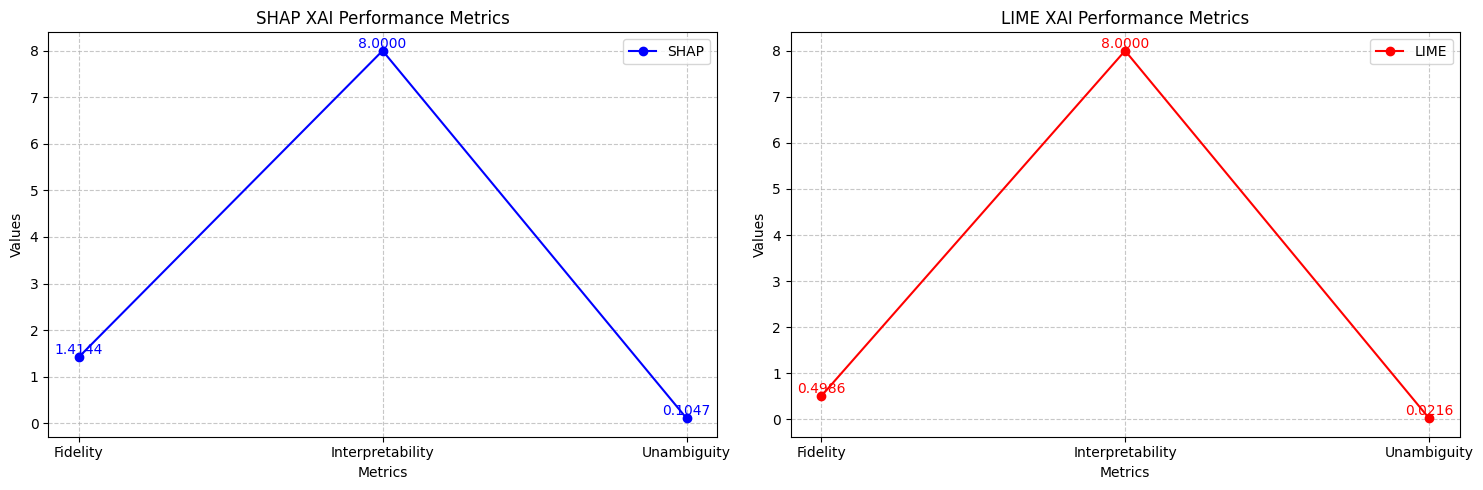

In [77]:
# SHAP and LIME Performance Metrics
data_shap = {
    'Metric': ['Fidelity', 'Interpretability', 'Unambiguity'],
    'Value': [1.4144, 8.00, 0.1047]
}

data_lime = {
    'Metric': ['Fidelity', 'Interpretability', 'Unambiguity'],
    'Value': [0.4986, 8.00, 0.0216]
}

shap_df = pd.DataFrame(data_shap)
lime_df = pd.DataFrame(data_lime)

# Plot SHAP and LIME Metrics Side by Side
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# SHAP Plot
axes[0].plot(shap_df['Metric'], shap_df['Value'], marker='o', linestyle='-', color='blue', label='SHAP')
for i, txt in enumerate(shap_df['Value']):
    axes[0].text(i, shap_df['Value'][i], f'{txt:.4f}', ha='center', va='bottom', fontsize=10, color='blue')
axes[0].set_xlabel('Metrics')
axes[0].set_ylabel('Values')
axes[0].set_title('SHAP XAI Performance Metrics')
axes[0].grid(True, linestyle='--', alpha=0.7)
axes[0].legend()

# LIME Plot
axes[1].plot(lime_df['Metric'], lime_df['Value'], marker='o', linestyle='-', color='red', label='LIME')
for i, txt in enumerate(lime_df['Value']):
    axes[1].text(i, lime_df['Value'][i], f'{txt:.4f}', ha='center', va='bottom', fontsize=10, color='red')
axes[1].set_xlabel('Metrics')
axes[1].set_ylabel('Values')
axes[1].set_title('LIME XAI Performance Metrics')
axes[1].grid(True, linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

Fidelity – How well the explanation method (like SHAP or LIME) represents the actual model’s behavior. Higher fidelity means the explanation is more accurate. (Closer to 1)

Interpretability – How easily a human can understand the explanation. Often measured by the number of features used in an explanation.

Unambiguity – How consistent and clear the explanations are across different instances. Lower unambiguity means more reliable explanations. (Closer to zero)

SHAP Fidelity (1.4144) is much higher → SHAP better aligns with the model’s predictions, meaning its explanations more accurately represent the model's true behavior.

SHAP Unambiguity (0.1047) is higher than LIME (0.0216) → SHAP explanations vary more, implying they might be more sensitive to input changes.


Interpretability (8 features for both) → Both methods are using the same number of features in their explanations, meaning they are equally complex.